<a href="https://colab.research.google.com/github/AnibalSJ/GCI_DataScience_AI_Matsuo_Lab/blob/main/lec11_unsupervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 11 Unsupervised Learning

**Chapter Introduction**
    
In Chapter 6, we will explore specific methods of unsupervised learning. Unsupervised learning refers to a learning model without target variables. This chapter focuses on **clustering**, **principal component analysis** and **market basket analysis**. Through this chapter, you will gain an understanding of the diverse applications and implementation methods of unsupervised learning.

Goal: To learn the types and overviews of unsupervised learning and acquire the ability to correctly construct and evaluate models.

- **[1 Unsupervised Learning](#1-教師なし学習)**
    - [1.1 Types of Unsupervised Models](#1.1-教師なしモデルの種類)
    - [1.2 Importing Libraries Used in This Chapter](#1.2-この章で使うライブラリのインポート)
<br><br>
- **[2 Clustering](#6.2-クラスタリング)**
    - [2.1 k-means Method](#2.1-k-means法)
    - [2.2 Clustering with the k-means Method](#2.2-k-means法でクラスタリングする)
    - [2.3 Clustering Financial Marketing Data](#2.3-金融マーケティングデータをクラスタリングする)   
    - [2.4 Estimating the Number of Clusters Using the Elbow Method](#2.4-エルボー法によるクラスター数の推定)    
    - [2.5 Interpreting Clustering Results](#2.5-クラスタリング結果の解釈)
    - [2.6 Methods Other Than the k-means Method](#2.6-k-means法以外の手法)
<br><br>
- **[3 Principal Component Analysis](#6.3-主成分分析)**
    - [3.1 Trying Principal Component Analysis](#3.1-主成分分析を試す)
    - [3.2 Pracitcal Examples of Principal Component Analysis](#3.2-主成分分析の実例)
<br><br>
- **[4 Market Basket Analysis and Association Rules](#6.4-マーケットバスケット分析とアソシエーションルール)**
    - [4.1 What Is Market Basket Analysis?](#4.1-マーケットバスケット分析とは)
    - [4.2 Loading Sample Data for Market Basket Analysis](#4.2-マーケットバスケット分析のためのサンプルデータを読み込む)
    - [4.3 Association Rules](#4.3-アソシエーションルール)
<br><br>
- **[5 Comprehensive Questions](#5-総合問題)**
    - [■ Comprehensive Question 1: Association Rules](#■-総合問題1-アソシエーションルール)

## 1 Unsupervised Learning

Keywords: Clustering, Principal Component Analysis, Market Basket Analysis, Association Analysis

Unsupervised learning is a modeling approach that does not rely on target variables. It is often used alongside supervised learning to build better models or as an exploratory analysis method to uncover structures and insights hidden in data. Through this chapter, you will gain an understanding of the diverse applications and implementation methods of unsupervised learning.

### 1.1 Types of Unsupervised Models
Unsupervised models can be broadly categorized as follows. In this chapter, you will learn how to implement and use them.

- Clustering

A method for classifying large datasets into several similar groups. It is commonly used in marketing approaches, such as customer segmentation (classifying customers) and targeting (narrowing down target audiences).

- Principal Component Analysis

A dimensionality reduction method used when dealing with many variables. It reduces the number of variables while retaining as much information as possible. In this chapter, you will focus on dimensionality reduction in the context of unsupervised learning.

- Market Basket Analysis (Association Analysis)

Often used to analyze shopping behavior in supermarkets, convenience stores, and websites. This method identifies relationships between items to uncover consumer purchasing patterns.

### 1.2 Importing Libraries Used in This Chapter
In this chapter, we will use the same libraries as in previous chapters, including Scikit-learn for machine learning. The content assumes that these libraries have been imported as shown below.

In [ ]:
# Data processing and analysis libraries
import numpy as np
import numpy.random as random
import scipy as sp
from pandas import Series, DataFrame
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
%matplotlib inline

# Machine learning libraries
import sklearn

# Display up to 3 decimal places
%precision 3

'%.3f'

## 2  Clustering
Keywords: Clustering, k-means, k-means++, Elbow Method, Silhouette Coefficient, Non-hierarchical Clustering, Hierarchical Clustering, Hard Clustering, Soft Clustering

In this section, we will look at **clustering**, a fundamental technique in unsupervised learning that helps us group similar data points based on their features. Clustering is incredibly useful for uncovering hidden patterns and structures within your data, whether you're segmenting customers, organizing images, or analyzing biological data.








### 2.1 k-means Method

The goal of clustering is to divide the given data into groups with high similarity. A cluster refers to a "group" or "flock."

For example, if we perform clustering on a dataset of cars with different body shapes, sports car and trucks would be divided into separate clusters because they have different body shapes and features.

The most widely used method in clustering is called the **k-means method**. The following diagram shows the result of clustering data on attributes (income, dept) using the k-means method, where customers are divided into three groups.




![comment](http://insidebigdata.com/wp-content/uploads/2013/12/Clustering.gif)

While it may seem obvious to humans to group this data, the k-means method achieves this through the following steps.

- Step 1: Plot the input data on a plane.
- Step 2: Randomly plot three points.
- Step 3: Label each random point as the centroid for Cluster 1, Cluster 2, and Cluster 3.
- Step 4: For each point in the input data, choose the nearest centroid among the three and assign its cluster number.
- Step 5: After assigning cluster numbers to all input data points, calculate the centroid (mean) for each cluster.
- Step 6: Use the three centroids calculated in Step 5 as the new cluster centroids.
- Step 7: Repeat Steps 4 through 6. The process stops when the maximum number of iterations is reached or the movement of the centroids becomes sufficiently small.

You can experience the k-means algorithm in action at the following site:
'''https://www.naftaliharris.com/blog/visualizing-k-means-clustering/'''


To perform k-means using Scikit-learn, you use the `KMeans` class from the `sklearn.cluster` module. If you omit the initialization parameter (`init='random'`), it defaults to **k-means++**.

k-means++ is a method for calculating the initial values in a way that spreads them out as much as possible, which generally provides more stable results compared to the regular k-means method. As mentioned earlier, k-means randomly places the initial centroids, which can lead to bias in their starting positions. k-means++ aims to address this issue.

Additionally, there is the **k-medoids method**, which uses the median (`medoid`) instead of the mean (`centroid`) for the centroid. While the mean may result in a non-existing data point, k-medoids uses the median, preventing the centroid from taking imaginary values. This method also has the advantage of being less affected by outliers.

>**[Let's Try It]**
>
>Let's research k-means, k-means++, and k-medoids. Explore their respective advantages, disadvantages, and how they are implemented.

### 2.2 Clustering with the k-means Method

In this section, we'll perform clustering using the k-means method with Scikit-learn.

#### Creating Training Data
We will create the training data using the make_blobs function from the `sklearn.datasets` module. The `make_blobs` function generates random numbers that follow a normal distribution with a standard deviation of 1.0 along the vertical and horizontal axes. It is primarily used to generate sample data for clustering.

In the following example, we specify `random_state`=10. This is the seed value used to generate the random numbers. We set it to 10 for this explanation in order to better spread out the plot. By default, the `make_blobs` function generates 100 random numbers in the range of 0 to 10 without any arguments.

Finally, we plot the generated random numbers using Matplotlib.


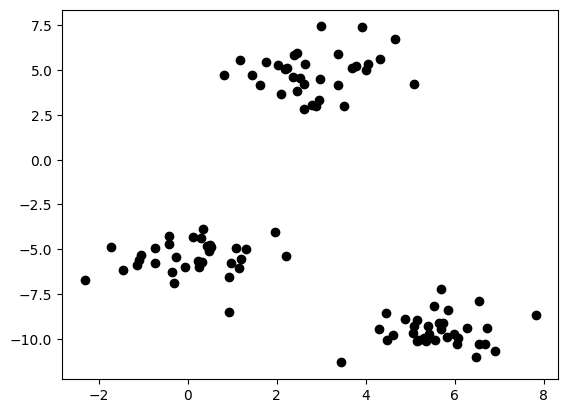

In [ ]:
# Importing k-means for clustering
from sklearn.cluster import KMeans

# Importing make_blobs for data generation
from sklearn.datasets import make_blobs

# Generating sample data
# Note: make_blobs returns two values, one of which we don't use, so it's received as "_"
X, _ = make_blobs(random_state=10)

# Plotting the graph
# The color option allows coloring the data points
plt.scatter(X[:,0],X[:,1],color='black')

#### Implementing clustering in scikit-learn using KMeans class

To learn using the k-means model and assign sequential cluster numbers to the clustering results, the program works as follows. The cluster numbers are assigned sequentially starting from 0.

First, initialize the `KMeans` class and create an object. In the example below, the `init` parameter defines the initialization method. By setting it to "`random`," the k-means method is used rather than k-means++. The `n_clusters` parameter sets the number of clusters.

Once the KMeans object is created, execute the fit method. This will compute the cluster centroids, and by executing the `predict` method, the cluster numbers will be predicted. There is also a `fit_predict` method that runs both fitting and prediction as a single process. However, if you plan to save the constructed model, it is generally better to run the fit method and the predict method independently.

In [ ]:
# Initializing the k-means class
kmeans = KMeans(init='random', n_clusters=3)

# Calculating the cluster centroids
kmeans.fit(X)

# Predicting the cluster numbers
y_pred = kmeans.predict(X)

#### Checking the Results
Let's visualize the learning results of k-means using a graph. For this, we will use the Pandas techniques learned in Chapter 3. First, we will concatenate the data using `concat`. We specify `axis=1` to concatenate the x-coordinates, y-coordinates, and cluster numbers horizontally.

For visualization, we extract the data for each cluster number and specify a color to plot it. By using the k-means method, we can confirm that the data has been successfully divided into the three groups we expected.

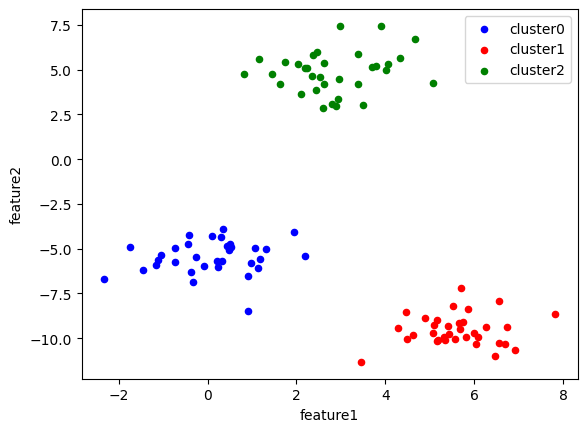

In [ ]:
# Concatenating data horizontally using concat (specifying axis=1)
merge_data = pd.concat([pd.DataFrame(X[:,0]), pd.DataFrame(X[:,1]), pd.DataFrame(y_pred)], axis=1)

# Specifying column names for the data
merge_data.columns = ['feature1','feature2','cluster']

# Visualizing the clustering results
ax = None
colors = ['blue', 'red', 'green']
for i, data in merge_data.groupby('cluster'):
    ax = data.plot.scatter(x='feature1', y='feature2', color=colors[i],
                                           label=f'cluster{i}', ax=ax)

### 2.3 Clustering Financial Marketing Data
Now, to deepen our understanding of how clustering results can be utilized, let's perform clustering using financial marketing data and examine the results in detail.

#### Analysis Requirement
The data comes from a financial institution and includes a variable indicating whether a customer applied for a term deposit account. Other variables include information on the campaign status and customer attributes. We will assume that this data is provided by a client with the following analysis request: "We don’t know what kind of customers we have, so please analyze the data."

If we consider a supervised learning approach, we would typically construct a model with the application for a time deposit account as the target variable. However, the client’s analysis request does not necessarily specify a target variable. In data analysis, it is common for analysts to use unsupervised learning (clustering) as the first step to deepen their understanding of the data.

#### Download and Load the Analysis Data
The data used for this analysis is the learning data provided at the following URL, specifically the bank-full.csv file included in the package.

http://archive.ics.uci.edu/static/public/222/bank+marketing.zip










In [ ]:
# Import libraries for downloading data from the web and handling zip files
import requests, zipfile
import io
import warnings
warnings.simplefilter('ignore')

# Specify the URL wehre the data is located
!wget "http://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
# Unzip the bank+marketing.zip file
!unzip "./bank+marketing.zip"
# Unzip the bank.zip file
!unzip "./bank.zip"

--2025-02-06 14:54:07--  http://archive.ics.uci.edu/static/public/222/bank+marketing.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘bank+marketing.zip’

bank+marketing.zip      [    <=>             ] 999.85K  1.01MB/s    in 1.0s    

2025-02-06 14:54:08 (1.01 MB/s) - ‘bank+marketing.zip’ saved [1023843]

Archive:  ./bank+marketing.zip
 extracting: bank.zip                
 extracting: bank-additional.zip     
Archive:  ./bank.zip
  inflating: bank-full.csv           
  inflating: bank-names.txt          
  inflating: bank.csv                


Next, we load the target data, `bank-full.csv`, using Pandas.　The delimiter is set using the `sep` parameter. The first 5 rows are displayed using the `head` method, as shown below.








In [ ]:
# Load the target data
bank = pd.read_csv('bank-full.csv', sep=';')

# Display the first 5 rows
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
ls

bank-additional.zip*  bank-full.csv       bank-names.txt  sample_data/
bank.csv              bank+marketing.zip  bank.zip*


The meaning of the data is described in the bank-names.txt file included in the zip file. Below is an excerpt from it. The input variables are the explanatory variables, and the output variable is the target variable. However, let's not focus on predicting the target variable here. In addition to continuous variables such as `age`, we can see that there are categorical variables such as `job` and `education`.

-Input variables:
- ##### bank client data:
1 - age (numeric)  
2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student","blue-collar","self-employed","retired","technician","services")  
3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
4 - education (categorical: "unknown","secondary","primary","tertiary")  
5 - default: has credit in default? (binary: "yes","no")  
6 - balance: average yearly balance, in euros (numeric)    
7 - housing: has housing loan? (binary: "yes","no")  
8 - loan: has personal loan? (binary: "yes","no")   
- ##### related with the last contact of the current campaign:
9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
10 - day: last contact day of the month (numeric)  
11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
12 - duration: last contact duration, in seconds (numeric)  
- ##### other attributes:
13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
15 - previous: number of contacts performed before this campaign and for this client (numeric)  
16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")  

-Output variable:
- ##### desired target
17 - y - has the client subscribed a term deposit? (binary: "yes","no")

#### Data Organization and Standardization
Let's check the number of records, the number of variables, and any missing data. By running the following program, we can see that the data consists of 45,211 rows and 17 columns. Additionally, we can confirm that there is no missing data.

In [ ]:
print('Data shape(X,y): {}'.format(bank.shape))
print('Number of missing values: {}'.format(bank.isnull().sum().sum()))

Data shape(X,y): (45211, 17)
Number of missing values: 0


To simplify the analysis, we will limit the variables under consideration to `age` (age), `balance` (annual income), `campaign` (number of contacts in the current campaign), and `previous` (number of contacts in previous campaigns). These variables have different units, so we will perform standardization, as we did in supervised learning, as a preprocessing step. This ensures that variables with larger values do not disproportionately influence the clustering model.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Selecting relevant columns
bank_sub = bank[['age','balance','campaign','previous']]

# Standardization
sc = StandardScaler()
sc.fit(bank_sub)
bank_sub_std = sc.transform(bank_sub)

In [ ]:
bank_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       45211 non-null  int64
 1   balance   45211 non-null  int64
 2   campaign  45211 non-null  int64
 3   previous  45211 non-null  int64
dtypes: int64(4)
memory usage: 1.4 MB


#### Clustering Process
After standardizing the data, we perform clustering using k-means. In this case, we set the number of clusters to 6. The method for determining the number of clusters will be explained later. Once the clustering process is complete, the labels_ attribute of the k-means object can be used to obtain an array of cluster numbers assigned to each data point. The following program converts the array into a pandas Series object, counts the number of data points in each cluster, and displays the cluster composition in a bar chart.








cluster_number
4    14454
0    23791
3     1286
2     3781
5      525
1     1374
Name: count, dtype: int64


Text(0, 0.5, 'count')

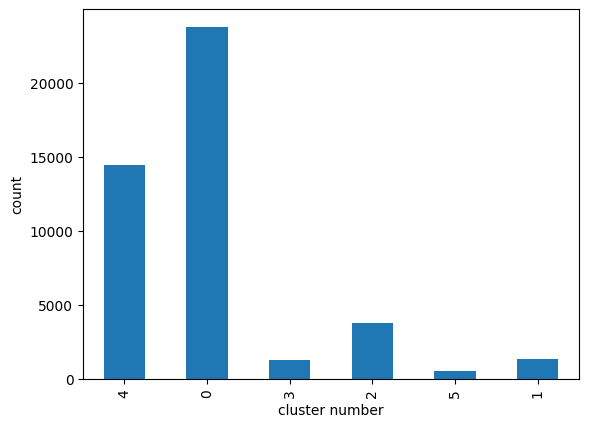

In [ ]:
# Initializing k-means class
kmeans = KMeans(init='random', n_clusters=6, random_state=0)

# Calculating the cluster centroids
kmeans.fit(bank_sub_std)

# Converting the cluster numbers to a pandas Series object
labels = pd.Series(kmeans.labels_, name='cluster_number')

# Displaying the cluster numbers and counts
print(labels.value_counts(sort=False))

# Plotting the graph
ax = labels.value_counts(sort=False).plot(kind='bar')
ax.set_xlabel('cluster number')
ax.set_ylabel('count')

Looking at the results above, we can see that groups in clusters 0 and 4 are relatively larger.

### 2.4  Estimating the Number of Clusters Using the Elbow Method
In this case, we have set the number of clusters to 6, but one method to estimate the number of clusters is the **elbow method**. The elbow method aims to determine the appropriate number of clusters by analyzing how the sum of distances between the cluster centroids and the data points within each cluster change accordingly with the number of clusters.

As the number of clusters increases from 1, each point will be assigned to a centroid that is closer, so this sum is expected to decrease accordingly.
As the number of clusters increase, it will reach the most appropriate number at some point. After that, the rate of decrease in this sum is expected to slow down.
Elbow method looks at this change in the rate of decrease to determine the appropriate number of clusters.

First, let's apply the elbow method to the data X generated by the `make_blobs` function from section 2.2. The sum of distances can be obtained from the `inertia_` attribute of the `KMeans` object. The sum of distances for cluster numbers from 1 to 10 is calculated and graphed, as shown in the following figure.

As can be seen from the results, when the number of clusters exceeds 3, the rate of decrease on the vertical axis drops sharply. Therefore, the appropriate number of clusters can be estimated to be 3. By examining the sum of distances, we can see that the slope of the decrease in the vertical axis changes at the ideal number of clusters. This shape resembles an elbow, which is why it is called the elbow method.

Text(0, 0.5, 'Distortion')

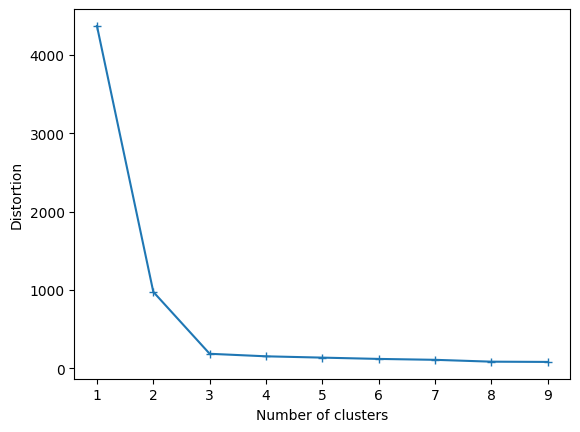

In [ ]:
# Estimating using the elbow method. Increase the number of clusters from 1 to 10 and calculate the sum of distances for each.
dist_list =[]
for i in range(1,10):
    kmeans= KMeans(n_clusters=i, init='random', random_state=0)
    kmeans.fit(X)
    dist_list.append(kmeans.inertia_)

# Plotting the graph
plt.plot(range(1,10), dist_list,marker='+')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')

Now that we understand the mechanism of the elbow method, let's try it on the financial data as well. Here, we plotted the sum of distances for the number of clusters from 1 to 20.

Text(0, 0.5, 'Distortion')

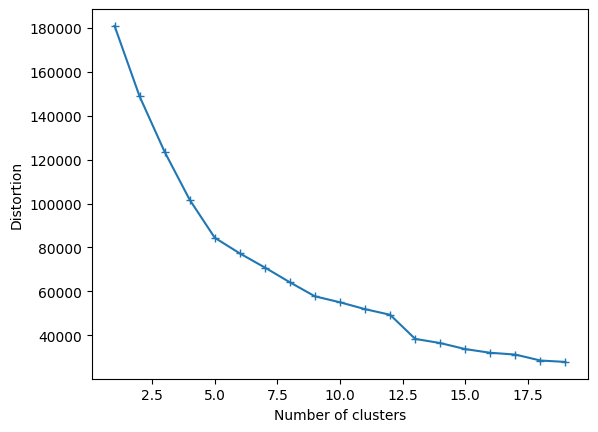

In [ ]:
# Estimating using the elbow method. We increase the nubmer of clusters from 1 to 20 and calculate the sum of distance for each
dist_list =[]
for i in range(1,20):
    kmeans= KMeans(n_clusters=i, init='random', random_state=0)
    kmeans.fit(bank_sub_std)
    dist_list.append(kmeans.inertia_)

# Displaying the graph
plt.plot(range(1,20), dist_list,marker='+')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')

While not as clear as the result from the `make_blobs` function, we can observe that the decrease in the sum of distances starts to slow down around cluster numbers 5–6. If no clear trend is observed using the elbow method, alternative methods such as calculating the **silhouette coefficient**, using domain-specific knowledge to decide on the cluster number, or proceeding with a manageable number of clusters based on the understanding of the data may be considered.

>**[Let's Try It]**
>
>Let's research the silhouette coefficient.

### 2.5 Interpreting Clustering Results
 Now, let's attempt to interpret the data using the results of the clustering process. First, we will concentrate on the clustering results obtained earlier to the original financial marketing data. This adds a new variable, `cluster_number`, to the far-right side of the data. This represents the cluster number to which each data point has been assigned.

In [ ]:
# Combine the cluster nubmer data with the finanicial institution data
bank_with_cluster = pd.concat([bank, labels], axis=1)

# Display the first 5 rows
bank_with_cluster.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,cluster_number
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,4
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,4
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,4
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0


Next, we will check the age groups within each cluster. To do this, we will use binning and the pivot function, which we learned earlier. The axis will be the cluster number (cluster_number) and age (age). The age will be divided into 5-year intervals starting from 15 years old, with the final group being from 65 to 100 years old.

In [ ]:
# Setting bin intervals for age grouping
bins = [15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 100]

# Splitting the data based on these intervals and assigning to qcut_age
qcut_age = pd.cut(bank_with_cluster.age, bins, right=False)

# Combining the cluster number and age group
df = pd.concat([bank_with_cluster.cluster_number, qcut_age], axis=1)

# Grouping by cluster number and age group
cross_cluster_age = df.groupby(['cluster_number', 'age']).size().unstack().fillna(0)
cross_cluster_age

age,"[15, 20)","[20, 25)","[25, 30)","[30, 35)","[35, 40)","[40, 45)","[45, 50)","[50, 55)","[55, 60)","[60, 65)","[65, 100)"
cluster_number,,,,,,,,,,,
0,45,708,3972,8272,6853,3941,0,0,0,0,0
1,0,20,130,327,306,186,145,117,71,38,34
2,1,18,233,782,872,739,587,337,175,32,5
3,0,11,74,240,219,205,156,141,156,48,36
4,0,0,0,0,0,1022,4529,3840,3479,850,734
5,1,5,55,119,99,92,53,53,41,6,1


The following counts the number of people in each age group:

In [ ]:
# Count the number of entries in each bin
hist_age = pd.value_counts(qcut_age)
hist_age

,count
age,
"[30, 35)",9740
"[35, 40)",8349
"[40, 45)",6185
"[45, 50)",5470
"[50, 55)",4488
"[25, 30)",4464
"[55, 60)",3922
"[60, 65)",974
"[65, 100)",810


Since the numbers alone are hard to interpret, let's calculate the proportion of each age group within the clusters and visualize it with a heatmap. In such cases, a heatmap, where the more frequent proportions are represented by darker colors, is useful. The heatmap is created using the `heatmap` function from the visualization library Seaborn. Additionally, we use apply method and lambda function to calculate the proportion for each age group.

<Axes: xlabel='age', ylabel='cluster_number'>

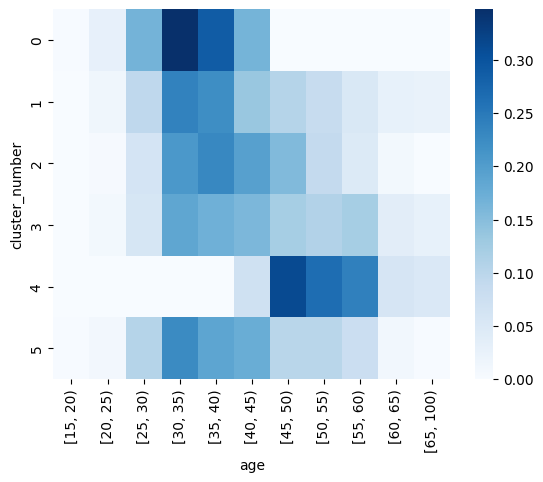

In [ ]:
sns.heatmap(cross_cluster_age.apply(lambda x : x/x.sum(), axis=1), cmap='Blues')

From the heatmap above, we can see that in cluster number 0, the proportion of people in the 30-40 age group is high, while in cluster number 4, the proportion of people in the 45-60 age group is high. From this result, we can conclude that these two clusters have an age bias.

Similarly, let's take a look at the variable "job," which represents occupation. Unlike age, job is a categorical variable. First, let's perform an aggregation. Since there are occupations with 0 people in some clusters, we are replacing NaN with 0.


In [ ]:
cross_cluster_job = bank_with_cluster.groupby(['cluster_number', 'job']).size().unstack().fillna(0)
cross_cluster_job

job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
cluster_number,,,,,,,,,,,,
0,3022,5426,702,413,4980,55,826,2496,814,4290,690,77
1,193,239,42,21,335,53,42,113,53,245,33,5
2,387,845,146,108,863,60,144,358,40,704,90,36
3,109,176,54,36,418,77,71,69,22,194,49,11
4,1414,2915,530,655,2733,2008,477,1077,3,2054,434,154
5,46,131,13,7,129,11,19,41,6,110,7,5


Next, let's plot the heatmap from the above aggregation.

<Axes: xlabel='job', ylabel='cluster_number'>

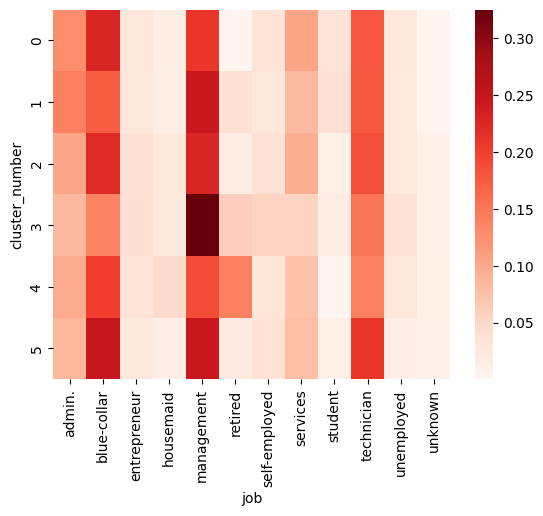

In [ ]:
sns.heatmap(cross_cluster_job.apply(lambda x : x/x.sum(), axis=1),cmap='Reds')

From the above heatmap, we can see that in cluster number 3, the proportion of management is particularly high, while in cluster number 0, the proportion of blue-collar workers is slightly higher.

Based on the results so far, we can interpret that cluster number 0 is a group with a high proportion of people in their 30s to 40s and slightly more blue-collar workers. In practice, more dimensions would be investigated. However, rather than repeating aggregation and visualization aimlessly, it's important to consider what actions are planned based on the analysis results and to develop a thoughtful analysis plan.

This concludes the brief introduction to interpreting clustering results.



### 2.6 Methods Other Than the k-means Method

Finally, I will add some supplementary information on the classification of clustering methods. The k-means method learned in this chapter belongs to a type of clustering known as **non-hierarchical clustering**. However, there are also methods that belong to **hierarchical clustering**.

In Scikit-learn, hierarchical clustering can be performed using the `AgglomerativeClustering` class from the `sklearn.cluster` module. It is recommended to also explore terms like dendrogram when researching this method.

Another classification of clustering methods is **soft clustering**. The k-means method is classified as **hard clustering**, where the cluster number for each data point is uniquely determined. In soft clustering, however, the probability of belonging to each cluster is calculated. For example, the probability of belonging to cluster 1 might be 70%, while the probability for cluster 2 is 30%.

For clustering customer preferences or hobbies, soft clustering may be more suitable than hard clustering. Choose the appropriate method based on the goal. Soft clustering can be performed using the `GaussianMixture` class in the `sklearn.mixture` module.



>**[Try It Out]**
>
>Let's research the hierarchical and non-hierarchical clustering mentioned above. Also, let's investigate the differences between soft clustering and hard clustering, their approaches, and check the execution methods of representative techniques.

####  <Practice Question 1>
Use the data generated with `make_blobs()` function as implemented below and perform clustering. How many clusters will you divide it into? Once divided, plot the result by coloring the individual cluster in different colors.

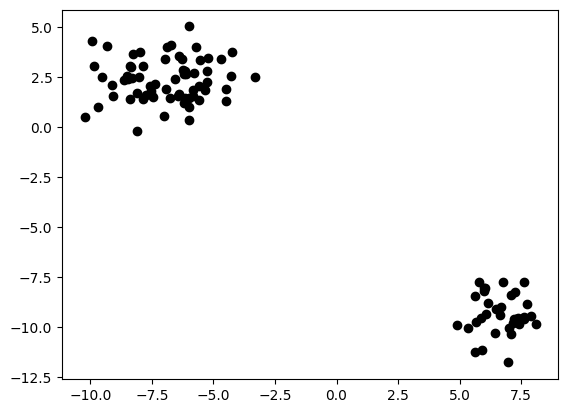

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Create dataset
X, y = make_blobs(random_state=52)
plt.scatter(X[:,0], X[:,1], color='black')

## WRITE ME

####  <Practice Question 2>
What would the result be if you performed k-means clustering with 4 clusters on the previously handled data, `bank_sub_std`? Similar to <Practice Question 6-1>, after obtaining the cluster numbers, analyze each cluster and interpret their characteristics. Also, what would happen if you set the number of clusters to 8? Additionally, what if you select variables other than `age`, `balance`, `campaign`, and `previous`?

## 3 Principal Component Analysis
Keywords: PCA, eigenvalue, eigenvector, dimensionality reduction, linear discriminant analysis

In this section, we will learn about **Principal Component Analysis (PCA)**.

As we have seen so far, data often includes many variables. In the previous financial marketing data, for example, there were various variables such as occupation and age. It is important to examine the relationships between explanatory variables and the target variable one by one, but as the number of explanatory variables increases, understanding those relationships becomes more challenging.

PCA can compress the number of variables without losing much of the information in the original data. This makes it widely used as a preprocessing step for exploratory analysis and when building predictive models. Please note that the PCA we are dealing with here is unsupervised dimensionality reduction, whereas supervised dimensionality reduction (such as Linear Discriminant Analysis) is also available. If you are interested, feel free to look it up.

You can visually understand the algorithm for dimensionality reduction in PCA through the following website:
'''https://setosa.io/ev/principal-component-analysis/ '''

### 3.1  Implementing Principal Component Analysis

Let's look at how Principal Component Analysis works using a simple sample dataset. The following program generates a 2-variable dataset using the `RandomState` object and plots the standardized data for each variable.

First, a `RandomState` object is created with the seed (initial random number value) set to 1 using `np.Random.RandomState(1)`.

Next, two random numbers are generated using the `rand` and `randn` functions. Note that the correlation coefficient between the variables is 0.889, which indicates a strong correlation between the two variables. Also, since the data is standardized, both variables have a mean of 0 and a variance of 1. If you want to understand why this correlation coefficient is high, please refer to the Appendix.

Correlation coefficient: 0.889


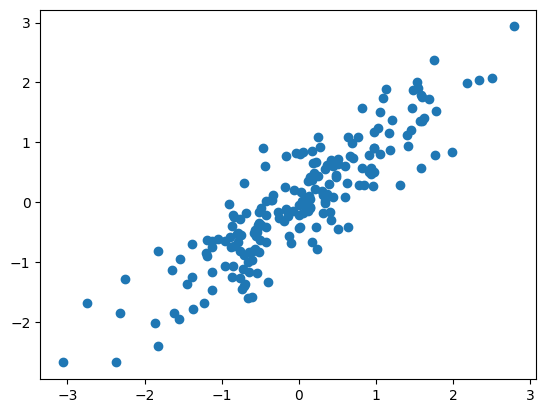

In [ ]:
from sklearn.preprocessing import StandardScaler

# Create a RandomState object
sample = np.random.RandomState(1)

# Generate two random numbers
X = np.dot(sample.rand(2, 2), sample.randn(2, 200)).T

# Standardize
sc = StandardScaler()
X_std = sc.fit_transform(X)

# Calculate the correlation coefficient and plot
print('Correlation coefficient: {:.3f}'.format(sp.stats.pearsonr(X_std[:, 0], X_std[:, 1])[0]))
plt.scatter(X_std[:, 0], X_std[:, 1])

#### Performing Principal Component Analysis
Principal component analysis (PCA) can be executed using the `PCA` class from the `sklearn.decomposition` module. When initializing the object, you specify how many dimensions you want to reduce the variables to, i.e., the number of principal components to extract, using the `n_components` parameter. Typically, a smaller value than the original number of variables is set (e.g., reducing from 30 variables to 5). However, in this case, it is set to 2, the same as the original data. By executing the `fit` method, the necessary information for extracting the principal components is learned (specifically, the eigenvalues and eigenvectors are calculated).


In [ ]:
# Import
from sklearn.decomposition import PCA

# Prinicipal Component Analysis
pca = PCA(n_components=2)
pca.fit(X_std)

PCA(n_components=2)

#### Confirming the Learning Results
Let's check the results of the PCA object. Below, we will examine the `components_`, `explained_variance_`, and `explained_variance_ratio_` attributes.

##### 1. `components_` Attribute
The `components_` attribute refers to the eigenvectors, which represent the directions of the new feature space discovered by PCA. The results are as follows:

The vector [-0.707, -0.707] corresponds to the first principal component (PC1).
The vector [-0.707, 0.707] corresponds to the second principal component (PC2).

In [ ]:
print(pca.components_)

[[ 0.707  0.707]
 [ 0.707 -0.707]]


#### 2. `explained_variance_` Attribute

The explained_variance_ attribute represents the variance of each principal component. As seen below, the variances of the two extracted principal components are 1.889 and 0.111, respectively.

The total sum of the variances being 2.0 is not a coincidence. The sum of the variances of the principal components matches the sum of the original variances of the (standardized) variables. This means that the variance (information) is preserved.

In [ ]:
print('Variance of each principal component: {}'.format(pca.explained_variance_))

Variance of each principal component: [1.899 0.111]


#### 3. `explained_variance_ratio_` Attribute
The `explained_variance_ratio_` attribute represents the proportion of variance captured by each principal component. The first value, 0.945, is obtained by dividing 1.889 by (1.889 + 0.111), meaning that the first principal component retains 94.5% of the original data's information.

In [ ]:
print('Proportion of variance for each principal component: {}'.format(pca.explained_variance_ratio_))

Proportion of variance for each principal component: [0.945 0.055]


Since the numbers alone are hard to interpret, let's visualize the principal components. The following arrows represent the direction of the new feature space obtained by principal component analysis. The first principal component is aligned in the direction of maximum variance. The other principal components are all orthogonal to its preceding principal components. In the example below, the vector [-0.707, -0.707] represents the first principal component, and [-0.707, 0.707] represents the direction of the second principal component, which are orthogonal to each other.

(-3.3534087054527717,
 3.079070151762556,
 -2.9610077757452697,
 3.2159825436132246)

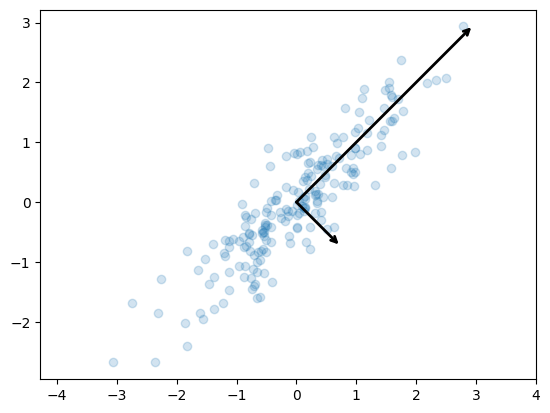

In [ ]:
# Parameter settings
arrowprops=dict(arrowstyle='->',
                linewidth=2,
                shrinkA=0, shrinkB=0)

# Function to draw arrows
def draw_vector(v0, v1):
    plt.gca().annotate('', v1, v0, arrowprops=arrowprops)

# Plotting the data
plt.scatter(X_std[:, 0], X_std[:, 1], alpha=0.2)

# Displaying the principal components
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)

plt.axis('equal')

For principle component analysis, the Python Data Science Handbook [Python Data Science Handbook](https://github.com/jakevdp/PythonDataScienceHandbook) and
[the concept of principal component analysis](https://logics-of-blue.com/principal-components-analysis/	) are also helpful references.

Again, the first principal component is the vector in the direction where the variance is maximized, relative to the original scatter plot. The vector in the direction with the second largest variance is the second principal component. The first and second principal components are orthogonal.

Now, consider the projection of each point from the original values onto the first principal component. This allows the original 2-dimensional data to be mapped onto the first principal component axis, reducing one dimension while retaining most of the data variance.

Finally, as a supplement, let's look at the following example to better understand the concept of dimensionality reduction. Below is a graph viewed in 3D, where the plot positions are color-coded.

![](https://sebastianraschka.com/images/blog/2014/kernel_pca/2014-09-14-kernel_pca_87_0.png)

Quoted from http://sebastianraschka.com/Articles/2014_kernel_pca.html

When this 3D data is reduced to 2D using principal component analysis, it appears as shown below. The horizontal axis, PC1, represents the first principal component, and the vertical axis, PC2, represents the second principal component. Not only is the data structure from the 3D case preserved, but the original positions are also reflected, as seen in the continuity of the colors. This shows that principal component analysis performs dimensionality reduction while preserving the original information.



![](https://sebastianraschka.com/images/blog/2014/kernel_pca/2014-09-14-kernel_pca_91_0.png)

Quoted from http://sebastianraschka.com/Articles/2014_kernel_pca.html

### 3.2 Principal Component Analysis in Practice
The explanation of how to perform principal component analysis and its conceptual image is now complete. Let's now look at how dimensionality reduction using principal component analysis can be useful in practice, by examining a specific case. Here, we will use breast cancer data to demonstrate the effectiveness of principal component analysis.

The breast cancer data can be loaded using the `load_breast_cancer` function from `sklearn.datasets`. The following shows how to load the data and visualize the distribution of each explanatory variable, with the target variable (`cancer.target`) categorized as "`malignant`" or "`benign`."



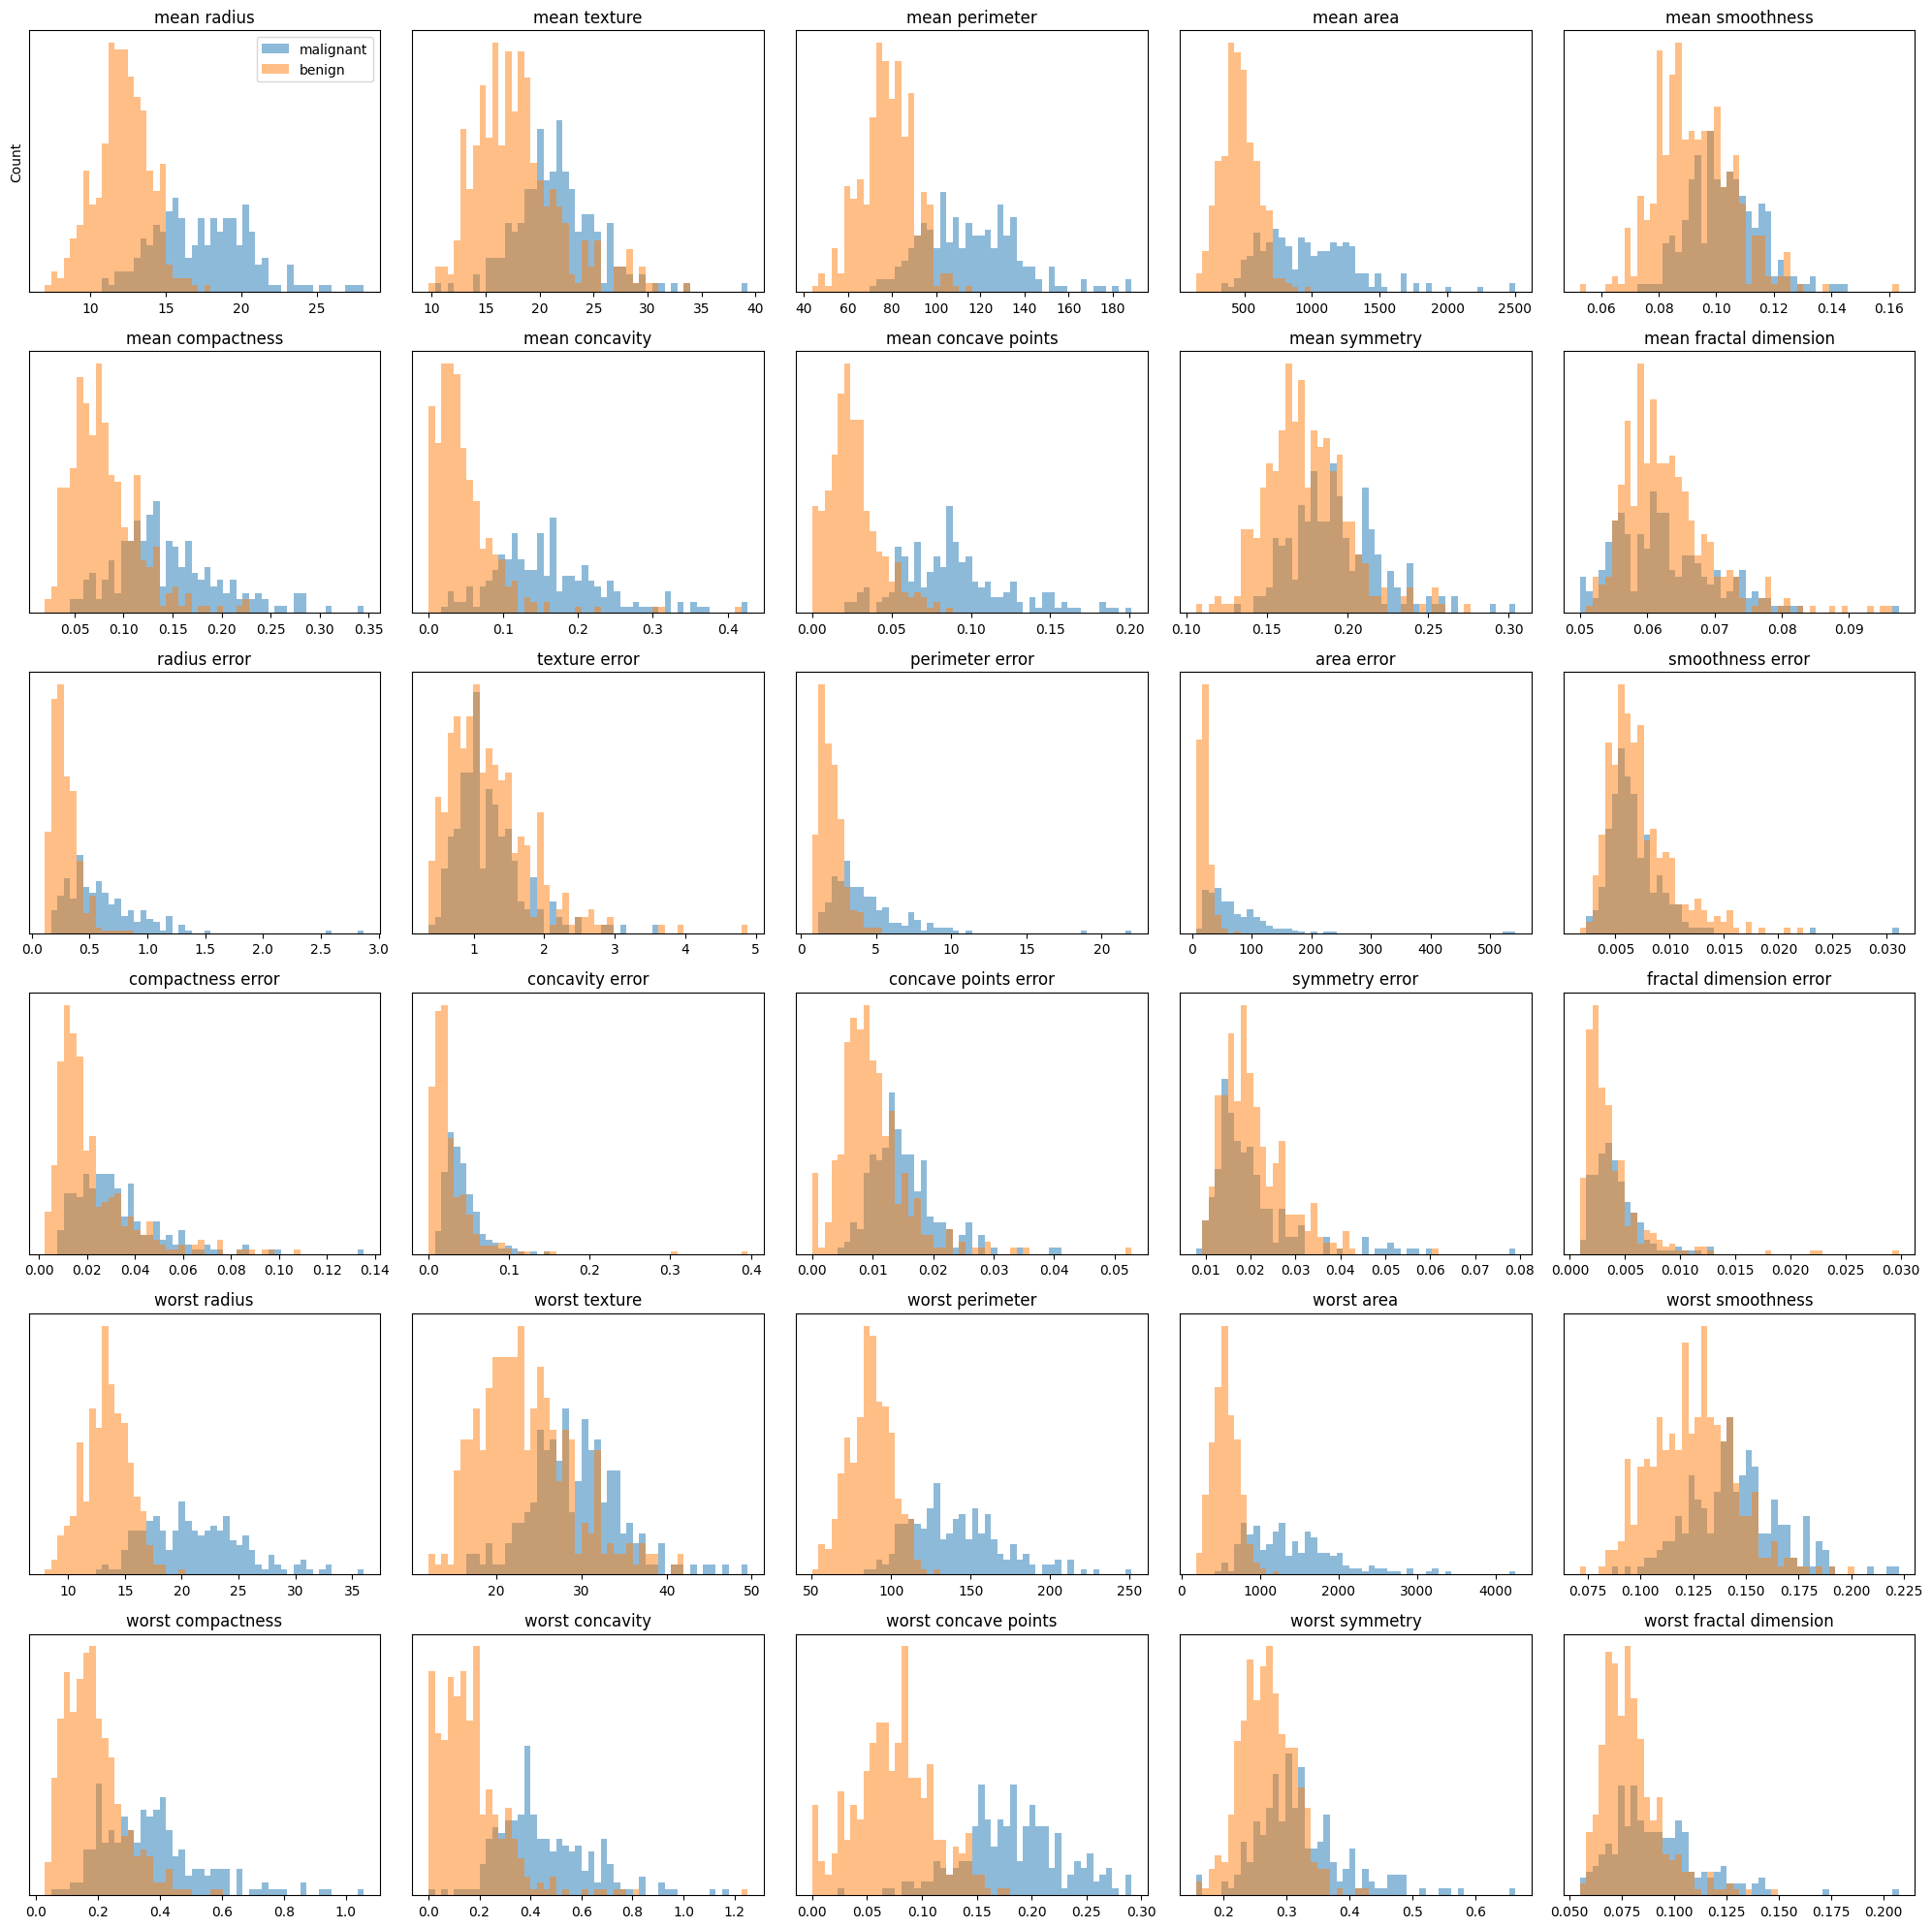

In [ ]:
# Importing breast cancer data
from sklearn.datasets import load_breast_cancer

# Loading breast cancer data
cancer = load_breast_cancer()

# Filtering the data to separate malignant (target = 0) and benign (target = 1) cases
malignant = cancer.data[cancer.target==0]
benign = cancer.data[cancer.target==1]

# Plot histograms with malignant cases in blue and benign cases in orange
# Each plot shows the relationship between each explanatory variable (e.g., mean radius) and the target variable
fig, axes = plt.subplots(6,5,figsize=(20,20))
ax = axes.ravel()
for i in range(30):
    _,bins = np.histogram(cancer.data[:,i], bins=50)
    ax[i].hist(malignant[:,i], bins, alpha=.5)
    ax[i].hist(benign[:,i], bins, alpha=.5)
    ax[i].set_title(cancer.feature_names[i])
    ax[i].set_yticks(())

# Label settings
ax[0].set_ylabel('Count')
ax[0].legend(['malignant','benign'],loc='best')
fig.tight_layout()

We will now use principal component analysis (PCA) to reduce the dimensions of these 20+ variables. Specifically, we will standardize the explanatory variables, perform PCA, and extract 2 principal components (`n_components` = 2).

By running the following program and checking the `explained_variance_ratio_` attribute, we can confirm that while the number of variables is reduced to 2, approximately 63% of the original information (i.e., 0.443 + 0.19) is condensed into the first and second principal components.




In [ ]:
# Standardization
sc = StandardScaler()
X_std = sc.fit_transform(cancer.data)

# Principal component anaylsis (PCA)
pca = PCA(n_components=2)
pca.fit(X_std)
X_pca = pca.transform(X_std)

# Display results
print('X_pca shape:{}'.format(X_pca.shape))
print('Explained variance ratio:{}'.format(pca.explained_variance_ratio_))

X_pca shape:(569, 2)
Explained variance ratio:[0.443 0.19 ]


The output X_pca shape: (569, 2) means that after performing Principal Component Analysis (PCA), the data has been transformed into a 2-dimensional space with 569 samples and 2 features (the first two principal components).  Each sample now has 2 values corresponding to the first and second principal components.

We will now visualize the data after dimensionality reduction. First, to prepare for the visualization, we will link the data of the first and second principal components with the corresponding target variable of the explanatory variables, and then separate the benign and malignant data.

In [ ]:
# Label columns for the first and second principal components
X_pca = pd.DataFrame(X_pca, columns=['pc1','pc2'])

# Concatenate the target variable
X_pca = pd.concat([X_pca, pd.DataFrame(cancer.target, columns=['target'])], axis=1)

# Separate malignant and benign data
pca_malignant = X_pca[X_pca['target']==0]
pca_benign = X_pca[X_pca['target']==1]

Now, let's plot this data. The result is shown below. `malignant` is plotted in red and `benign` in blue. You can see that it's possible to draw a boundary between malignant and benign.

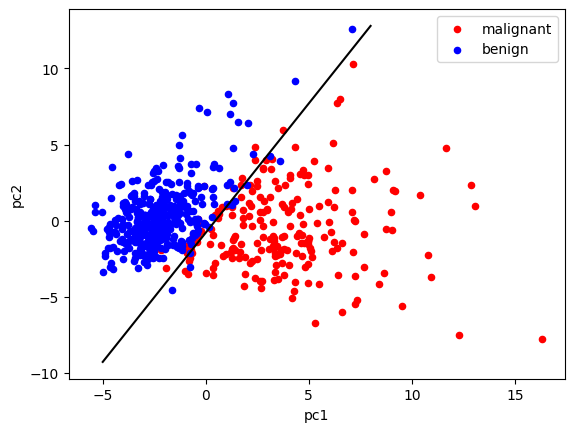

In [ ]:
# Plot malignant data
ax = pca_malignant.plot.scatter(x='pc1', y='pc2', color='red', label='malignant');

# Plot benign data
pca_benign.plot.scatter(x='pc1', y='pc2', color='blue', label='benign', ax=ax);

# Approximate boundary line
x = np.arange(-5, 9)
y = 1.7 * x - 0.8
ax.plot(x, y, color="black")

Looking at this graph, we can see that in this case, the two principal components almost perfectly separate the classes of the target variable. When there are many variables and it's unclear which ones to use for analysis, performing principal component analysis can help in the following ways: (1) clarifying the relationship between each principal component and the target variable, and (2) interpreting the relationship between the original variables and the target variable based on findings from (1). This approach will advance data understanding.

Additionally, keep in mind that principal component analysis can also be useful when you want to reduce the number of variables when building predictive models (dimensionality reduction). (Details on this will be covered in Chapter 9.) Finally, remember that the correlation coefficients between each principal component and the original explanatory variables are referred to as factor loadings. This can be used as a method in step (2) mentioned earlier.

####  <Practice Question 3>
Use the `load_iris` function from the `sklearn.datasets` module to load the Iris dataset, and perform principal component analysis (PCA) on `iris.data`. The number of principal components to extract should be set to 2. Additionally, analyze the relationship between the data reduced to the second principal component and the target variable (`iris.target`) using visualizations, such as graphs.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris = load_iris()

sc = StandardScaler()
sc.fit(iris.data)
X_std = sc.transform(iris.data)

## WRITE ME

## 4 Market Basket Analysis and Association Rules
Keywords: Association Rules, Support, Confidence, Lift

In this section, we will learn about the **Market Basket Analysis**.

### 4.1 What is Market Basket Analysis?

Market Basket Analysis analyzes the relationships between products purchased together, such as the likelihood of purchasing product B when product A is bought. It is named after the "basket" of items that pass through a supermarket checkout counter, which is the basic unit of analysis. This analysis is also referred to as Basket Analysis or Association Analysis.

The results of Market Basket Analysis are known as **Association Rules**, which describe the relationship between products, such as "If a person buys product A, they are likely to buy product B."

A well-known example is the "beer and diapers" rule. It suggests that fathers who buy diapers are also likely to purchase beer, which has become a popular (and somewhat mythical) example.

For consumer goods manufacturers and retailers, understanding which products are often bought together is a crucial topic. Useful association rules are applied in marketing campaign design and recommendation systems. In this section, we will introduce basic metrics such as **support**, **confidence**, and **lift**, which are used to evaluate the usefulness of Association Rules.




### 4.2 Loading Sample Data for Market Basket Analysis

In this section, we will use the purchase history data, which is a type of transaction data, to demonstrate Market Basket Analysis.

The purchase history data is often referred to as transaction data. We will load this data using the variable name `trans`. Note that this dataset is relatively large, with more than 500,000 records, so it may take some time to load.

In [ ]:
# Download data from the UCI website
!wget "http://archive.ics.uci.edu/static/public/352/online+retail.zip"
# Unzip the downloaded ZIP file
!unzip "./online+retail.zip"

--2025-02-06 14:54:52--  http://archive.ics.uci.edu/static/public/352/online+retail.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘online+retail.zip’

online+retail.zip       [        <=>         ]  22.62M  9.83MB/s    in 2.3s    

2025-02-06 14:54:55 (9.83 MB/s) - ‘online+retail.zip’ saved [23715478]

Archive:  ./online+retail.zip
 extracting: Online Retail.xlsx      


The following execution example shows the first 5 records using `head` method.

Note: In the purchase history data, `InvoiceNo` represents the invoice number. Transactions with the same `InvoiceNo` correspond to items listed in the same invoice. Therefore, items with the same `InvoiceNo` were purchased together in the same transaction.

Additionally, depending on your environment, you may need to install the xlrd module by running `pip3 install xlrd`.

In [ ]:
# Reading the file and displaying it
file_url = './Online Retail.xlsx'
trans = pd.ExcelFile(file_url)
trans = trans.parse('Online Retail')
trans.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


#### Data Organization and Verification

In this transaction history data, the first character of the `InvoiceNo` indicates the status of the transaction. "5" represents regular data, "C" represents cancellations, and "A" represents unknown data. First, we'll add the first character of `InvoiceNo` as a separate variable called `cancel_flg`. After adding it, we'll count and aggregate the records by each value of `cancel_flg`. In practice, aggregation conditions greatly depend on the analysis purpose and data management status, so it's important to verify these thoroughly.

In [ ]:
# Adding the first character of InvoiceNo as cancel_flg
trans['cancel_flg'] = trans.InvoiceNo.map(lambda x:str(x)[0])

# Group by cancel_flg and aggregate the data
trans.groupby('cancel_flg').size()

,0
cancel_flg,
5,532618
A,3
C,9288


We will only work with the data where the `InvoiceNo` starts with "5" (normal data) and where the `CustomerID` is not missing. To filter these data, use the following code. If you are unsure about this process, try reviewing the Pandas chapter or searching for "Pandas filter" on a search engine.

In [ ]:
trans = trans[(trans.cancel_flg == '5') & (trans.CustomerID.notnull())]

### 4.3 Association Rules

Now that the data is prepared, let's explain association rules. First, let's check the top 5 product numbers based on the nubmer of purchases. The product numbers are stored in the `stockCode` column.

By using the `value_counts` method of the Pandas `Series` object, we can get the record count for each unique value, sorted in descending order by default.

In [ ]:
# Change the `StockCode` column to string type
trans = trans.astype({'StockCode': 'str'})
# Count the number of occurences for each `StockCode` and display the first 5 entries
trans['StockCode'].value_counts().head(5)

,count
StockCode,
85123A,2035
22423,1724
85099B,1618
84879,1408
47566,1397


In the following, we will explain the association rules, support, confidence, and lift using first-place product "85123A" and the third-place product "85099B as examples.

#### Support

The **support** of an association rule refers to the number of baskets (`InvoiceNos`) in which **both a particular product (in this case, 85123A) and another product (85099B) were sold together**, or the proportion of the total transactions in which this occurs.

Below, we will calculate the support of the association rule,

**"If product 85123A is bought, then product 85099B is also bought."**

First, count the numbers of baskets (`InvoiceNos`) appearing in the transaction data (all purchase data).

First, extract all `InvoiceNos` as trans_all.

By using a set, we can keep the `InvoiceNos` without duplicates. Next, extract the baskets that contain both products as `trans_ab`. To do this, extract the `InvoiceNos` containing each product (here referred to as `trans_a` and `trans_b`), and then take the intersection of these sets.

Note: When working with sets, a set is an unordered collection that contains unique elements. The intersection (common elements) is obtained by using the `&` operator on sets.

In [ ]:
# Extract all Invoice as trans_all
trans_all = set(trans.InvoiceNo)

# Extract data for purchase of item 85123A as trans_a
trans_a = set(trans[trans['StockCode']=='85123A'].InvoiceNo)
print(len(trans_a))

# Extract data for purchase of item 85099B as trans_b
trans_b = set(trans[trans['StockCode']=='85099B'].InvoiceNo)
print(len(trans_b))

# Extract data for purchases of both items 85123A and 85099B as trans_ab
trans_ab = trans_a & trans_b
print(len(trans_ab))

1978
1600
252


The support of a rule is the number of baskets containing both items included in the rule or their proportion of the total. It can be calculated as follows:

In [ ]:
# Display the number of baskets containing both items in trans_ab
print('Number of baskets containing both items:{}'.format(len(trans_ab)))
print('Proportion of baskets containing both items to the total:{:.3f}'.format(len(trans_ab)/len(trans_all)))

Number of baskets containing both items:252
Proportion of baskets containing both items to the total:0.014


The value 0.014 is obtained, but whether this is high or low depends on relative comparison, so it cannot be judged definitively.

In general, rules with low support are often less useful, so support is sometimes used as a cutoff criterion.

Additionally, support can be calculated not only for the rule itself but also for the items that make up the rule.

For example, the support for item 85123A can be calculated as follows. Be sure to clarify the purpose of your analysis to determine whether you need the support of the rule or the support of the items that make up the rule.

In [ ]:
print('Number of baskets containing item 85123A:{}'.format(len(trans_a)))
print('Proportion of baskets containing item 85123A to the total:{:.3f}'.format(len(trans_a)/len(trans_all)))

Number of baskets containing item 85123A:1978
Proportion of baskets containing item 85123A to the total:0.107


#### Confidence

Confidence represents the **proportion of purchases of a certain item A that also include a certain item B**.

Below, we calculate the rule,

**"If item 85123A is purchased, then item 85099B is also purchased."**

In [ ]:
print('Confidence:{:.3f}'.format(len(trans_ab)/len(trans_a)))

Confidence:0.127


Conversely, the confidence for the rule **"if item 85099B is purchased, then item 85123A is also purchased"** is calculated as follows:

In [ ]:
print('Confidence:{:.3f}'.format(len(trans_ab)/len(trans_b)))

Confidence:0.158


High confidence suggests that cross-selling between products is likely. Therefore, when aiming to encourage customers to purchase additional products (such as other items), high-confidence items are often used to determine which products to offer. However, relying solely on confidence values can sometimes lead to incorrect judgments about cross-selling tendencies. Therefore, it is common to also consider the following lift values.

#### Lift

In the association rule "if item A is purchased, then item B is purchased," the lift is the value obtained by dividing the confidence of the rule (in %) by the support of item B (in %).

In other words, the lift value represents the **ratio of the purchase rate of item B when item A is purchased to the overall purchase rate of item B across all baskets**. Naturally, if the lift value is greater than 1.0, it indicates that cross-selling between the items is more likely. If the lift value is less than 1.0, it suggests that cross-selling is less likely.

Below, we calculate the lift for the rule,

**"If item 85123A is purchased, then item 85099B is also purchased."**

In [ ]:
# Calculate the purchase rate of item B in the overall baskets
support_b = len(trans_b) / len(trans_all)

# Calculate the purchase rate of item B when item A is purchased
confidence = len(trans_ab) / len(trans_a)

# Calculate the lift value
lift = confidence / support_b
print('lift:{:.3f}'.format(lift))

lift:1.476


Even if the confidence value is high, if the lift value is below 1.0, it may not be suitable as a basis for recommending products to customers. Depending on the purpose of the analysis, it is useful to combine both the confidence and lift values.

This concludes the explanation of basket analysis. In this case, association rules were extracted for the entire dataset, but if rules are extracted based on store areas, store types, customer clusters, etc., more useful rules might be identified.

####  <Practice Question 4>

Using the purchase history data from Section 4 "Market Basket Analysis and Association Rules," calculate the support, confidence, and lift values for other combinations of products of your choice.

## 5 Comprehensive Questions

### ■ Comprehensive Question 1 Association Rules

Using the purchase history data from Section 4, which combination of products has the highest support? However, calculate this for products (`StockCode`) that have more than 1,000 records.

(Hint: When extracting product combinations, the `itertools` module is useful. If you're not sure how to use it, try searching for "Python itertools.")

**Acknowledgement**:
The following two datasets were used:

1. http://archive.ics.uci.edu/static/public/222/bank+marketing.zip
2. http://archive.ics.uci.edu/static/public/352/online+retail.zip

Source: Markelle Kelly, Rachel Longjohn, Kolby Nottingham,
The UCI Machine Learning Repository, https://archive.ics.uci.edu

- Citation for Dataset 1:
[Moro et al., 2014] S. Moro, P. Cortez and P. Rita. A Data-Driven Approach to Predict the Success of Bank Telemarketing. Decision Support Systems, Elsevier, 62:22-31, June 2014
- Citation for Dataset 2:  
Daqing Chen, Sai Liang Sain, and Kun Guo, Data mining for the online retail industry: A case study of RFM model-based customer segmentation using data mining, Journal of Database Marketing and Customer Strategy Management, Vol. 19, No. 3, pp. 197â€“208, 2012 (Published online before print: 27 August 2012. doi: 10.1057/dbm.2012.17).